# 02 - Exploración inicial de datos

### Por: Carlos Javier Palacios Sanchez

### Fecha: 21/08/2026

### Descripción

**Requerimiento** ([issue #9](https://github.com/CarlosP1005/Heart---Data-Science-Project/issues/9)).
Realizar una exploración general de los datos para verificar los tipos, comprender las
características y el esquema, y solucionar los problemas básicos relacionados. Siguiendo
los pasos de
[esta guía](https://joserzapata.github.io/post/ciencia-datos-proyecto-python/2-exploration/).

**Proyecto:** Predicción de enfermedad cardíaca (`Heart---Data-Science-Project`)
**Etapa del ciclo de vida:** 2 - Exploración
**Rama:** `feature/exploracion-inicial`
**Entrada:** `notebooks/1-data/corazon.csv`
**Salida:** `data/02_intermediate/corazon_tipificado.parquet`

---

## 0. Qué se hace en este notebook

| # | Punto del requerimiento | Sección |
|---|---|---|
| 1 | Descripción general de los datos | 3 |
| 2 | Unificar la forma como se representan los valores nulos | 4 |
| 3 | Convertir los datos a su tipo correcto y corregirlos si es necesario | 5 |
| 4 | Almacenar el dataset final en un formato adecuado (`.parquet`) | 7 |

### Alcance: qué **no** se hace aquí

Esta etapa se ocupa del **esquema**, no del contenido. La regla que se sigue es estricta y
conviene declararla desde el principio:

> **Ninguna fila entra ni sale.** El archivo de salida tiene exactamente las mismas 3 030
> filas que el de entrada, con los mismos datos. Lo único que cambia es *cómo están
> representados*: los faltantes de una sola forma y cada columna con un tipo uniforme.

Por eso aquí **no** se eliminan duplicados, **no** se imputan faltantes y **no** se
descartan registros incompletos. Todas esas son decisiones que dependen del modelo que se
vaya a entrenar y corresponden a la etapa 4 (*feature engineering*). Mantener la frontera
limpia tiene una ventaja concreta: esta transformación es **reversible y auditable**, y
cualquiera puede verificar que no se perdió información por el camino.

Lo que sí se corrige son los problemas de **representación**: espacios sobrantes que
parten una categoría en dos, valores basura que ocupan una celda sin significar nada, y
números guardados como texto.

## 1. Configuración e importación de librerías

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

print(f"pandas  {pd.__version__}")
print(f"numpy   {np.__version__}")
print(f"pyarrow {pyarrow.__version__}")

pandas  3.0.5
numpy   2.4.6
pyarrow 25.0.1


In [2]:
RUTA_RAIZ = Path.cwd().resolve()
while not (RUTA_RAIZ / "pyproject.toml").exists() and RUTA_RAIZ.parent != RUTA_RAIZ:
    RUTA_RAIZ = RUTA_RAIZ.parent

RUTA_CRUDOS = RUTA_RAIZ / "notebooks" / "1-data" / "corazon.csv"
RUTA_DICCIONARIO = RUTA_RAIZ / "notebooks" / "1-data" / "datos_corazon_Info.txt"
RUTA_INTERMEDIA = RUTA_RAIZ / "data" / "02_intermediate"
RUTA_INTERMEDIA.mkdir(parents=True, exist_ok=True)

if str(RUTA_RAIZ / "src") not in sys.path:
    sys.path.insert(0, str(RUTA_RAIZ / "src"))

print(f"Raíz del proyecto : {RUTA_RAIZ}")
print(f"Datos crudos      : {RUTA_CRUDOS.relative_to(RUTA_RAIZ)}")
print(
    f"Salida            : {(RUTA_INTERMEDIA / 'corazon_tipificado.parquet').relative_to(RUTA_RAIZ)}"
)

Raíz del proyecto : /home/claude/repo
Datos crudos      : notebooks/1-data/corazon.csv
Salida            : data/02_intermediate/corazon_tipificado.parquet


## 2. Carga de los datos crudos

Se carga el archivo con **dos opciones deliberadas** que no son las de `read_csv` por
defecto:

- **`dtype=str`** — se lee todo como texto. Si se deja que pandas infiera los tipos, una
  columna numérica que contenga una sola cadena corrupta se convierte silenciosamente en
  `object`, y el problema queda invisible. Leyendo todo como texto, la inferencia de tipos
  pasa a ser una **decisión explícita** de este notebook en lugar de un efecto secundario.
- **`keep_default_na=False`** — pandas *no* convierte nada a `NaN` automáticamente. Así se
  puede ver **literalmente** qué hay en cada celda, incluidas las cadenas vacías, y decidir
  después qué cuenta como faltante. Es el punto de partida obligatorio para el punto 2 del
  requerimiento.

In [3]:
datos_crudos = pd.read_csv(RUTA_CRUDOS, dtype=str, keep_default_na=False, na_filter=False)

print(f"Registros : {datos_crudos.shape[0]:,}")
print(f"Columnas  : {datos_crudos.shape[1]}")
print(f"Memoria   : {datos_crudos.memory_usage(deep=True).sum() / 1e6:.3f} MB")
datos_crudos.head()

Registros : 3,030
Columnas  : 14
Memoria   : 0.517 MB


,age,sex,chest_pain,rest_bp,chol,fbs,rest_ecg,max_hr,exang,old_peak,slope,ca,thal,disease
0,63,Male,typical,145,233,1,left ventricular hypertrophy,150,0,2.3,3,0.0,fixed,0
1,67,Male,asymptomatic,160,286,0,left ventricular hypertrophy,108,1,1.5,2,3.0,normal,1
2,67,Male,asymptomatic,120,229,0,left ventricular hypertrophy,129,1,2.6,2,2.0,reversable,1
3,37,Male,nonanginal,130,250,0,normal,187,0,3.5,3,0.0,normal,0
4,41,Female,nontypical,130,204,0,left ventricular hypertrophy,172,0,1.4,1,0.0,normal,0


### 2.1 Diccionario de datos

Contenido de `notebooks/1-data/datos_corazon_Info.txt`, que es el contrato contra el cual
se validará todo lo demás. Sin este documento no habría forma de distinguir un valor
corrupto de uno legítimo: `2345` en la columna `sex` sólo es un error **porque el
diccionario dice que ahí van `Male` o `Female`**.

In [4]:
print(RUTA_DICCIONARIO.read_text(encoding="utf-8", errors="replace"))

En este dataset, cada fila representan datos realizados a pacientes
y si el paciente tiene problemas del corazon

Este dataset se usa para crear un sistema con aprendizaje de maquina que permita
determinar  automaticamente si un pacciente tiene problemas de corazon basado
en los datos de sus examenes.

El trabajo del primer Modulo de programacion analitica solamente es 
la parte de preparacion de datos. 

Este dataset es una modificacion, el dataset original se encuentra en:
https://www.kaggle.com/ronitf/heart-disease-uci

Nota: No usar el dataset original

* DATOS:
- age:	age in years	
- sex:	Male or Female	
- chest_pain:	typical, asymptomatic, nonanginal, nontypical	
- rest_bp:	resting blood pressure (in mm Hg on admission to the hospital)	
- chol:	serum cholestoral in mg/dl	
- fbs:	(fasting blood sugar > 120 mg/dl) (1 = true	 0 = false)
- rest_ecg:	resting electrocardiographic results (0, 1, 2)	
- max_hr:	maximum heart rate achieved	
- exang:	exercise induced angina (1 = yes	 0 = no

| Atributo | Descripción | Tipo esperado |
|---|---|---|
| `age` | Edad en años | Entero |
| `sex` | `Male` / `Female` | Categórico nominal |
| `chest_pain` | Tipo de dolor torácico: `typical`, `nontypical`, `nonanginal`, `asymptomatic` | Categórico nominal |
| `rest_bp` | Presión arterial en reposo (mm Hg) | Entero |
| `chol` | Colesterol sérico (mg/dl) | Entero |
| `fbs` | Glucemia en ayunas > 120 mg/dl (1 = sí, 0 = no) | **Booleano** |
| `rest_ecg` | ECG en reposo: `normal`, `left ventricular hypertrophy`, `ST-T wave abnormality` | Categórico nominal |
| `max_hr` | Frecuencia cardíaca máxima alcanzada | Entero |
| `exang` | Angina inducida por ejercicio (1 = sí, 0 = no) | **Booleano** |
| `old_peak` | Depresión del segmento ST inducida por ejercicio | Decimal |
| `slope` | Pendiente del segmento ST en el pico del ejercicio (1, 2, 3) | Entero **ordinal** |
| `ca` | Nº de vasos principales coloreados por fluoroscopía (0-3) | Entero (conteo) |
| `thal` | Talio: `normal`, `fixed`, `reversable` | Categórico nominal |
| `disease` | **Variable objetivo**: 1 = enfermedad, 0 = sano | **Booleano** |

Nótese que **tres columnas que parecen numéricas son en realidad booleanas** (`fbs`,
`exang`, `disease`) y que ninguna columna es de tipo fecha. Guardarlas como enteros
funcionaría, pero pierde la intención: un `1` en `fbs` no es una cantidad, es un sí.

## 3. Descripción general de los datos

### 3.1 Lo primero que hay que mirar: qué tipos infiere pandas por su cuenta

Antes de tocar nada, vale la pena ver qué habría pasado con una lectura normal
(`pd.read_csv` sin argumentos). Es el diagnóstico más rápido de la salud de un archivo.

In [5]:
inferencia = pd.read_csv(RUTA_CRUDOS)

comparacion_tipos = pd.DataFrame(
    {
        "tipo_inferido_por_pandas": inferencia.dtypes.astype(str),
        "tipo_esperado": {
            "age": "entero",
            "sex": "categórico",
            "chest_pain": "categórico",
            "rest_bp": "entero",
            "chol": "entero",
            "fbs": "booleano",
            "rest_ecg": "categórico",
            "max_hr": "entero",
            "exang": "booleano",
            "old_peak": "decimal",
            "slope": "entero ordinal",
            "ca": "entero (conteo)",
            "thal": "categórico",
            "disease": "booleano",
        },
    }
)
ES_TEXTO = {"object", "str", "string"}
comparacion_tipos["quedo_como_texto"] = comparacion_tipos["tipo_inferido_por_pandas"].isin(ES_TEXTO)

n_texto = int(comparacion_tipos["quedo_como_texto"].sum())
print(f"Columnas que pandas NO logró convertir a número: {n_texto} de {len(comparacion_tipos)}")
print(
    f"Únicas convertidas: {comparacion_tipos.index[~comparacion_tipos['quedo_como_texto']].tolist()}"
)
comparacion_tipos

Columnas que pandas NO logró convertir a número: 13 de 14
Únicas convertidas: ['fbs']


,tipo_inferido_por_pandas,tipo_esperado,quedo_como_texto
age,str,entero,True
sex,str,categórico,True
chest_pain,str,categórico,True
rest_bp,str,entero,True
chol,str,entero,True
fbs,float64,booleano,False
rest_ecg,str,categórico,True
max_hr,str,entero,True
exang,str,booleano,True
old_peak,str,decimal,True


El resultado es demoledor y es el síntoma central del archivo: **13 de las 14 columnas
vuelven como texto**. La única que pandas logra convertir a número es `fbs`.

`age`, `rest_bp`, `chol` y `old_peak` contienen números, pero basta **una sola celda** con
`'fggfds'` para que pandas se rinda y trate la columna entera como texto. Ninguna operación
aritmética funcionaría sobre ellas: `datos["age"].mean()` daría error o, peor, concatenaría
cadenas.

(El tipo concreto depende de la versión: pandas 3.0 lo llama `str` y las versiones
anteriores `object`. El problema es el mismo.)

Y `fbs`, la única que sí se convierte, ilustra el segundo problema: llega como **`float64`**
en lugar de entero, porque el `NaN` de NumPy sólo existe en coma flotante. Es un sí/no
representado como `0.0` y `1.0`. Lo mismo le pasa a `ca` en el archivo original, donde el
conteo de vasos sanguíneos está escrito literalmente como `0.0`, `1.0`, `2.0` — y no
existen 1.5 arterias.

### 3.2 Resumen por columna

In [6]:
def describir(df: pd.DataFrame) -> pd.DataFrame:
    """Tabla de diagnóstico: tipo, celdas vacías, cardinalidad y muestra de valores.

    Cuenta como vacía tanto la cadena vacía como el `NaN`, para que la tabla sirva igual
    antes y después de unificar los faltantes.
    """
    vacias = (df.isna() | df.astype("object").eq("")).sum()
    resumen = pd.DataFrame(
        {
            "tipo": df.dtypes.astype(str),
            "n_vacias": vacias,
            "n_unicos": df.replace("", np.nan).nunique(dropna=True),
            "ejemplos": [
                sorted(set(df[c].replace("", np.nan).dropna().astype(str)))[:4] for c in df.columns
            ],
        }
    )
    resumen["%_vacias"] = (resumen["n_vacias"] / len(df) * 100).round(2)
    return resumen[["tipo", "n_vacias", "%_vacias", "n_unicos", "ejemplos"]]


describir(datos_crudos)

,tipo,n_vacias,%_vacias,n_unicos,ejemplos
age,str,30,0.99,43,"[29, 34, 35, 37]"
sex,str,61,2.01,5,"[2345, 45, 765, Female]"
chest_pain,str,83,2.74,7,"[2345, 2435, 3456, asymptomatic]"
rest_bp,str,81,2.67,52,"[100, 101, 102, 104]"
chol,str,85,2.81,154,"[126, 131, 141, 149]"
fbs,str,97,3.20,2,"[0, 1]"
rest_ecg,str,193,6.37,8,"[3563, 36653, 435647, 5653]"
max_hr,str,171,5.64,92,"[103, 105, 106, 108]"
exang,str,151,4.98,4,"[0, 1, adfs, f]"
old_peak,str,150,4.95,42,"[0.0, 0.1, 0.2, 0.3]"


La columna `n_unicos` —que ya excluye las celdas vacías— es la que delata el problema:

| Columna | Valores distintos según el diccionario | Valores distintos en el archivo |
|---|---|---|
| `sex` | 2 | **5** |
| `chest_pain` | 4 | **7** |
| `rest_ecg` | 3 | **8** |
| `thal` | 3 | **7** |
| `disease` (objetivo) | 2 | **7** |
| `exang` | 2 | **4** |

Ninguna de esas columnas puede tener más valores de los que declara el diccionario. Los
sobrantes no son categorías raras que nadie documentó: son basura. La columna `ejemplos` lo
confirma a simple vista —`2345` en `sex`, `adfs` en `exang`, `fsdg` en `disease`— y se
cuantifican uno por uno en la sección 4.

Vale la pena mirar también `ca`: sus ejemplos son `0.0`, `1.0`, `2.0`, `3.0`. Es un conteo
de vasos sanguíneos escrito con decimal, un rastro de que en algún punto pasó por un
`float64`.

### 3.3 Estructura del archivo: duplicados y filas sin contenido

In [7]:
duplicados_exactos = int(datos_crudos.duplicated().sum())
filas_vacias = int((datos_crudos == "").all(axis=1).sum())
filas_unicas = len(datos_crudos.drop_duplicates())

print(f"Filas totales             : {len(datos_crudos):,}")
print(f"Filas únicas              : {filas_unicas:,}")
print(
    f"Duplicados exactos        : {duplicados_exactos:,} ({duplicados_exactos / len(datos_crudos):.1%})"
)
print(f"Filas completamente vacías: {filas_vacias}")
print()
print("Nº de veces que se repite cada fila única:")
print(datos_crudos.value_counts().value_counts().sort_index().to_string())

Filas totales             : 3,030
Filas únicas              : 568
Duplicados exactos        : 2,462 (81.3%)
Filas completamente vacías: 15

Nº de veces que se repite cada fila única:
count
1     255
2       9
7       5
8      89
9      95
10    114
15      1


**El 81 % del archivo son duplicados exactos.** De 3 030 registros sólo 568 son
combinaciones distintas de valores, y cada fila única aparece repetida un número variable
de veces. Hay además **15 filas completamente vacías**: 14 columnas sin un solo dato.

Esto reconfigura el tamaño real del problema —no son 3 030 pacientes— pero, como se
declaró en la sección 0, **no se elimina nada aquí**. Se deja registrado como el hallazgo
principal para la etapa 4, que es donde corresponde decidir qué hacer con ellos. Adelantar
esa decisión a la etapa de exploración haría irreversible una transformación que debería
ser sólo de formato.

## 4. Unificar la representación de los valores nulos

Éste es el punto 2 del requerimiento y el más interesante del notebook, porque el archivo
representa "no hay dato" de **dos maneras distintas**, y sólo una de las dos es visible.

### 4.1 Primera forma: la celda vacía

Se buscan de forma exhaustiva todos los tokens que suelen usarse para marcar un faltante.

In [8]:
TOKENS_NULOS = {
    "",
    "na",
    "n/a",
    "n.a.",
    "null",
    "none",
    "nan",
    "nil",
    "?",
    "-",
    "--",
    ".",
    "missing",
    "sin dato",
    "s/d",
    "desconocido",
    "unknown",
}

registros_nulos = []
for columna in datos_crudos.columns:
    serie = datos_crudos[columna]
    vacias = int((serie == "").sum())
    solo_espacios = int(((serie != "") & (serie.str.strip() == "")).sum())
    normalizado = serie.str.strip().str.lower()
    otros = sorted(set(serie[normalizado.isin(TOKENS_NULOS - {""})]))
    registros_nulos.append((columna, vacias, solo_espacios, otros))

tokens_encontrados = pd.DataFrame(
    registros_nulos, columns=["atributo", "cadena_vacia", "solo_espacios", "otros_tokens"]
)
tokens_encontrados

,atributo,cadena_vacia,solo_espacios,otros_tokens
0,age,30,0,[]
1,sex,61,0,[]
2,chest_pain,83,0,[]
3,rest_bp,81,0,[]
4,chol,85,0,[]
5,fbs,97,0,[]
6,rest_ecg,193,0,[]
7,max_hr,171,0,[]
8,exang,151,0,[]
9,old_peak,150,0,[]


Resultado: **el archivo usa una sola convención explícita, la cadena vacía**. No hay `NA`,
ni `?`, ni `-`, ni celdas con sólo espacios. En un archivo real esto rara vez pasa, y por
eso valía la pena verificarlo en lugar de asumirlo — si hubiera aparecido un `?` mezclado
con celdas vacías, tratarlos de forma distinta habría sesgado todo el análisis posterior.

### 4.2 Segunda forma: el nulo disfrazado de dato

Aquí está el problema real. Estas celdas **no están vacías** y por lo tanto pandas las
reporta como presentes, pero no significan nada:

- `sex` contiene `2345`, `45`, `765`
- `chest_pain` contiene `2345`, `2435`, `3456`
- `age` contiene `fggfds`, `sdg`
- `disease` —la variable objetivo— contiene `fsg`, `gsfdg`, `g`, `sf`, `fsdg`

Son **más peligrosos que las celdas vacías** precisamente porque son invisibles:
`df.isna().sum()` devuelve cero para ellos, cualquier auditoría rápida los da por buenos, y
sólo revientan más adelante —al convertir tipos, al entrenar un modelo, o peor, no
revientan y contaminan el resultado en silencio.

**Unificar la representación de los nulos significa, en este archivo, convertir esta
basura en faltantes explícitos.** Se detecta con dos criterios distintos según el tipo de
columna:

- **Categóricas**: cualquier valor que no pertenezca al dominio declarado en el
  diccionario de datos.
- **Numéricas**: cualquier valor que no se pueda convertir a número, o que caiga fuera de
  un rango fisiológicamente plausible.

In [9]:
OBJETIVO = "disease"

DOMINIOS_CATEGORICOS: dict[str, set[str]] = {
    "sex": {"Male", "Female"},
    "chest_pain": {"typical", "nontypical", "nonanginal", "asymptomatic"},
    "rest_ecg": {"normal", "left ventricular hypertrophy", "ST-T wave abnormality"},
    "thal": {"normal", "fixed", "reversable"},
}

# Rangos fisiológicamente plausibles: acotan errores de digitación.
RANGOS_NUMERICOS: dict[str, tuple[float, float]] = {
    "age": (18.0, 110.0),
    "rest_bp": (60.0, 260.0),
    "chol": (80.0, 700.0),
    "max_hr": (50.0, 250.0),
    "old_peak": (0.0, 10.0),
}

# Columnas discretas con un conjunto cerrado de códigos válidos.
CODIGOS_VALIDOS: dict[str, set[float]] = {
    "fbs": {0.0, 1.0},
    "exang": {0.0, 1.0},
    "slope": {1.0, 2.0, 3.0},
    "ca": {0.0, 1.0, 2.0, 3.0},
    OBJETIVO: {0.0, 1.0},
}

print(f"Columnas categóricas : {list(DOMINIOS_CATEGORICOS)}")
print(f"Columnas continuas   : {list(RANGOS_NUMERICOS)}")
print(f"Columnas con códigos : {list(CODIGOS_VALIDOS)}")

Columnas categóricas : ['sex', 'chest_pain', 'rest_ecg', 'thal']
Columnas continuas   : ['age', 'rest_bp', 'chol', 'max_hr', 'old_peak']
Columnas con códigos : ['fbs', 'exang', 'slope', 'ca', 'disease']


### 4.3 Antes de validar: los espacios sobrantes

Hay una trampa que hay que desactivar **antes** de comparar contra los dominios. Si se
valida directamente, el resultado es desastroso por una razón puramente tipográfica.

In [10]:
espacios = []
for columna in DOMINIOS_CATEGORICOS:
    serie = datos_crudos[columna]
    con_espacios = serie[(serie != "") & (serie != serie.str.strip())]
    espacios.append((columna, len(con_espacios), sorted(set(con_espacios))[:2]))

print(
    pd.DataFrame(espacios, columns=["atributo", "n_valores_con_espacios", "ejemplos"]).to_string(
        index=False
    )
)
print()
print("Valores distintos de rest_ecg tal como están en el archivo (repr):")
for valor, n in datos_crudos["rest_ecg"].value_counts().head(5).items():
    print(f"  {valor!r:45} -> {n:,}")

  atributo  n_valores_con_espacios                        ejemplos
       sex                       0                              []
chest_pain                       0                              []
  rest_ecg                    1387 [left ventricular hypertrophy ]
      thal                       0                              []

Valores distintos de rest_ecg tal como están en el archivo (repr):
  'normal'                                      -> 1,409
  'left ventricular hypertrophy '               -> 1,387
  ''                                            -> 193
  'ST-T wave abnormality'                       -> 36
  '5678'                                        -> 1


**`left ventricular hypertrophy ` tiene un espacio al final, en las 1 387 filas donde
aparece.** Es decir: *todos* los registros de esa categoría. Si se validara contra el
dominio del diccionario sin normalizar primero, la comparación fallaría para las 1 387 y se
convertirían en faltantes — se destruiría el **46 % de la columna** por un carácter
invisible.

Es el tipo de error que no produce ningún mensaje y que sólo se detecta mirando los valores
con `repr()`. Por eso el orden de las operaciones importa: **normalizar el texto primero,
validar después**.

In [11]:
def normalizar_texto(df: pd.DataFrame) -> pd.DataFrame:
    """Recorta espacios sobrantes y colapsa espacios internos repetidos."""
    df = df.copy()
    for columna in DOMINIOS_CATEGORICOS:
        df[columna] = df[columna].str.strip().str.replace(r"\s+", " ", regex=True)
    return df


def unificar_nulos(df: pd.DataFrame) -> pd.DataFrame:
    """Deja una sola representación de faltante: `NaN`.

    Convierte a `NaN` tanto las cadenas vacías como los valores que no pertenecen al
    dominio declarado de su columna.
    """
    df = df.replace("", np.nan)
    for columna, dominio in DOMINIOS_CATEGORICOS.items():
        df[columna] = df[columna].where(df[columna].isin(dominio))
    for columna, (limite_inf, limite_sup) in RANGOS_NUMERICOS.items():
        valores = pd.to_numeric(df[columna], errors="coerce")
        df[columna] = valores.where(valores.between(limite_inf, limite_sup))
    for columna, codigos in CODIGOS_VALIDOS.items():
        valores = pd.to_numeric(df[columna], errors="coerce")
        df[columna] = valores.where(valores.isin(codigos))
    return df


faltantes_antes = (datos_crudos == "").sum()

datos_normalizados = normalizar_texto(datos_crudos)
datos_unificados = unificar_nulos(datos_normalizados)

faltantes_despues = datos_unificados.isna().sum()

balance_nulos = pd.DataFrame(
    {
        "celdas_vacias": faltantes_antes,
        "faltantes_tras_unificar": faltantes_despues,
        "basura_descubierta": faltantes_despues - faltantes_antes,
    }
)
balance_nulos["%_faltante_final"] = (
    balance_nulos["faltantes_tras_unificar"] / len(datos_unificados) * 100
).round(2)
balance_nulos

,celdas_vacias,faltantes_tras_unificar,basura_descubierta,%_faltante_final
age,30,32,2,1.06
sex,61,64,3,2.11
chest_pain,83,86,3,2.84
rest_bp,81,83,2,2.74
chol,85,87,2,2.87
fbs,97,97,0,3.20
rest_ecg,193,198,5,6.53
max_hr,171,172,1,5.68
exang,151,153,2,5.05
old_peak,150,152,2,5.02


In [12]:
total_basura = int(balance_nulos["basura_descubierta"].sum())
total_vacias = int(balance_nulos["celdas_vacias"].sum())
celdas = datos_crudos.size

print(f"Celdas totales                    : {celdas:,}")
print(f"Faltantes visibles (celda vacía)  : {total_vacias:,} ({total_vacias / celdas:.2%})")
print(f"Faltantes ocultos (valor basura)  : {total_basura:,} ({total_basura / celdas:.2%})")
print(f"Faltantes tras unificar           : {total_vacias + total_basura:,}")
print()
print("Los 33 valores basura que pandas reportaba como datos válidos:")
for columna in datos_crudos.columns:
    presentes = datos_normalizados[columna].replace("", np.nan).dropna()
    invalidos = sorted(set(presentes[datos_unificados[columna].isna().loc[presentes.index]]))
    if invalidos:
        print(f"  {columna:12} -> {invalidos}")

Celdas totales                    : 42,420
Faltantes visibles (celda vacía)  : 1,647 (3.88%)
Faltantes ocultos (valor basura)  : 33 (0.08%)
Faltantes tras unificar           : 1,680

Los 33 valores basura que pandas reportaba como datos válidos:
  age          -> ['fggfds', 'sdg']
  sex          -> ['2345', '45', '765']
  chest_pain   -> ['2345', '2435', '3456']
  rest_bp      -> ['fsgh', 'wety']
  chol         -> ['sfdywe', 'wtey']
  rest_ecg     -> ['3563', '36653', '435647', '5653', '5678']
  max_hr       -> ['adfs']
  exang        -> ['adfs', 'f']
  old_peak     -> ['afd', 'asd']
  slope        -> ['afd']
  ca           -> ['afd']
  thal         -> ['365635463', '53646', '56', '87654']
  disease      -> ['fsdg', 'fsg', 'g', 'gsfdg', 'sf']


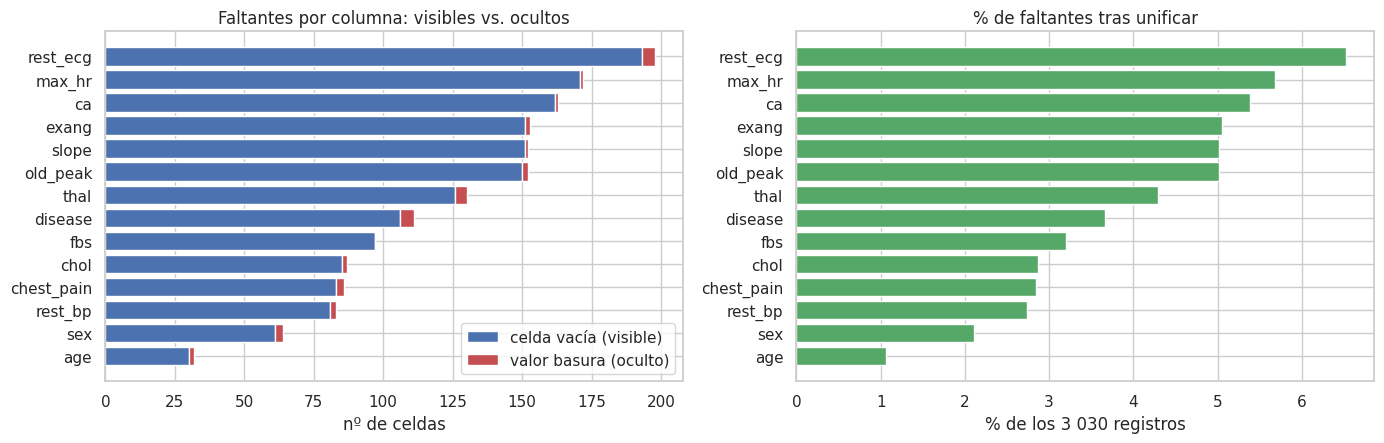

In [13]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 4.6))

orden = balance_nulos.sort_values("%_faltante_final", ascending=False).index
ejes[0].barh(
    orden, balance_nulos.loc[orden, "celdas_vacias"], color="#4C72B0", label="celda vacía (visible)"
)
ejes[0].barh(
    orden,
    balance_nulos.loc[orden, "basura_descubierta"],
    left=balance_nulos.loc[orden, "celdas_vacias"],
    color="#C44E52",
    label="valor basura (oculto)",
)
ejes[0].invert_yaxis()
ejes[0].set_title("Faltantes por columna: visibles vs. ocultos")
ejes[0].set_xlabel("nº de celdas")
ejes[0].legend()

ejes[1].barh(orden, balance_nulos.loc[orden, "%_faltante_final"], color="#55A868")
ejes[1].invert_yaxis()
ejes[1].set_title("% de faltantes tras unificar")
ejes[1].set_xlabel("% de los 3 030 registros")

plt.tight_layout()
plt.show()

### Lectura

Aparecen **33 faltantes que estaban ocultos** tras un valor aparentemente válido. Es una
cifra pequeña frente a los 1 647 faltantes visibles —un 2 % del total—, y ésa es
exactamente la razón por la que son peligrosos: son demasiado pocos para notarlos en un
resumen y suficientes para romper una conversión de tipo o para meter una categoría
fantasma en un modelo.

Los cinco de `disease` merecen mención aparte. Es la **variable objetivo**: un `'gsfdg'`
ahí no es un dato faltante cualquiera, es un registro que no se puede usar ni para entrenar
ni para evaluar. Quedan marcados como `NaN` y la etapa 4 los descartará.

Después de esta sección **hay una sola forma de decir "no hay dato": `NaN`**, que es lo
que pedía el punto 2 del requerimiento.

## 5. Conversión al tipo de dato correcto

Punto 3 del requerimiento. Ahora que los faltantes están unificados se puede asignar a cada
columna un tipo uniforme.

### 5.1 Por qué no basta con `float64`

La conversión ingenua (`pd.to_numeric`) deja todo en `float64`, y eso trae tres problemas:

1. **Miente sobre la naturaleza del dato.** `ca` es un conteo de vasos sanguíneos: `2.0` es
   una representación incorrecta de "dos arterias". Lo mismo con `age` o `rest_bp`.
2. **Pierde la intención de las booleanas.** `fbs`, `exang` y `disease` son sí/no. Como
   `float64` invitan a calcular promedios y correlaciones que no tienen sentido semántico.
3. **Desperdicia memoria.** Las categóricas como texto libre ocupan mucho más que un
   `category`, que guarda un diccionario de valores y códigos enteros.

La solución son los **tipos nullable de pandas** (`Int16`, `Float32`, `boolean`), que
admiten `pd.NA` sin degradar a coma flotante. Son los que permiten tener una columna que es
**entera y con faltantes al mismo tiempo** — algo imposible con el `int64` de NumPy.

| Columna | Tipo destino | Por qué |
|---|---|---|
| `age`, `rest_bp`, `chol`, `max_hr` | `Int16` | Enteros con faltantes. `Int16` cubre hasta 32 767, de sobra para edades, presiones y colesterol |
| `old_peak` | `Float32` | Único decimal real (depresión del ST en mm, un decimal) |
| `fbs`, `exang`, `disease` | `boolean` | Son sí/no, no cantidades |
| `slope`, `ca` | `Int8` | Enteros pequeños: 1-3 y 0-3 |
| `sex`, `chest_pain`, `rest_ecg`, `thal` | `category` | Conjunto cerrado y pequeño de valores repetidos |

In [14]:
TIPOS_DESTINO: dict[str, str] = {
    "age": "Int16",
    "sex": "category",
    "chest_pain": "category",
    "rest_bp": "Int16",
    "chol": "Int16",
    "fbs": "boolean",
    "rest_ecg": "category",
    "max_hr": "Int16",
    "exang": "boolean",
    "old_peak": "Float32",
    "slope": "Int8",
    "ca": "Int8",
    "thal": "category",
    "disease": "boolean",
}


def convertir_tipos(df: pd.DataFrame) -> pd.DataFrame:
    """Asigna a cada columna su tipo definitivo, conservando los faltantes como `pd.NA`."""
    df = df.copy()
    for columna, tipo in TIPOS_DESTINO.items():
        if tipo == "category":
            df[columna] = df[columna].astype("category")
        elif tipo == "boolean":
            df[columna] = df[columna].astype("Int8").astype("boolean")
        else:
            df[columna] = df[columna].astype(tipo)
    return df


datos_tipificados = convertir_tipos(datos_unificados)

resultado_tipos = pd.DataFrame(
    {
        "tipo_original": inferencia.dtypes.astype(str),
        "tipo_final": datos_tipificados.dtypes.astype(str),
        "n_faltantes": datos_tipificados.isna().sum(),
    }
)
resultado_tipos

,tipo_original,tipo_final,n_faltantes
age,str,Int16,32
sex,str,category,64
chest_pain,str,category,86
rest_bp,str,Int16,83
chol,str,Int16,87
fbs,float64,boolean,97
rest_ecg,str,category,198
max_hr,str,Int16,172
exang,str,boolean,153
old_peak,str,Float32,152


### 5.2 Efecto sobre la memoria

In [15]:
memoria_cruda = datos_crudos.memory_usage(deep=True).sum()
memoria_final = datos_tipificados.memory_usage(deep=True).sum()

comparacion_memoria = pd.DataFrame(
    {
        "como_texto_KB": (datos_crudos.memory_usage(deep=True) / 1024).round(1),
        "tipificado_KB": (datos_tipificados.memory_usage(deep=True) / 1024).round(1),
    }
).drop(index="Index")
comparacion_memoria["reduccion_%"] = (
    (1 - comparacion_memoria["tipificado_KB"] / comparacion_memoria["como_texto_KB"]) * 100
).round(1)

print(f"Memoria como texto : {memoria_cruda / 1e6:.3f} MB")
print(f"Memoria tipificada : {memoria_final / 1e6:.3f} MB")
print(f"Reducción          : {1 - memoria_final / memoria_cruda:.1%}")
comparacion_memoria.sort_values("reduccion_%", ascending=False)

Memoria como texto : 0.517 MB
Memoria tipificada : 0.094 MB
Reducción          : 81.8%


,como_texto_KB,tipificado_KB,reduccion_%
rest_ecg,72.0,3.0,95.8
chest_pain,54.5,3.0,94.5
thal,44.9,3.0,93.3
sex,37.1,3.0,91.9
ca,32.1,5.9,81.6
fbs,26.5,5.9,77.7
slope,26.5,5.9,77.7
disease,26.5,5.9,77.7
exang,26.5,5.9,77.7
rest_bp,32.3,8.9,72.4


## 6. Validación del resultado

Comprobaciones obligatorias antes de dar por buena la etapa. La más importante es la
primera: **verificar que no se perdió ni se inventó información**, que es la promesa que se
hizo en la sección 0.

In [16]:
def valores_presentes(df: pd.DataFrame) -> int:
    """Número de celdas con dato (no faltantes)."""
    return int(df.notna().sum().sum())


verificaciones = {
    "mismo número de filas": len(datos_tipificados) == len(datos_crudos),
    "mismo número de columnas": datos_tipificados.shape[1] == datos_crudos.shape[1],
    "mismo orden de columnas": list(datos_tipificados.columns) == list(datos_crudos.columns),
    "ninguna columna quedó como 'object'": not any(
        str(t) == "object" for t in datos_tipificados.dtypes
    ),
    "una sola representación de nulo (NaN)": bool(
        datos_tipificados.select_dtypes(include="category").isin([""]).sum().sum() == 0
    ),
    "categóricas dentro de su dominio": all(
        set(datos_tipificados[c].dropna().unique()) <= dominio
        for c, dominio in DOMINIOS_CATEGORICOS.items()
    ),
    "continuas dentro de su rango": all(
        bool(datos_tipificados[c].dropna().between(lo, hi).all())
        for c, (lo, hi) in RANGOS_NUMERICOS.items()
    ),
    "sin datos ganados por el camino": valores_presentes(datos_tipificados)
    <= valores_presentes(datos_crudos.replace("", np.nan)),
}

for descripcion, resultado in verificaciones.items():
    print(f"[{'OK ' if resultado else 'FALLA'}] {descripcion}")

if not all(verificaciones.values()):
    fallidas = [k for k, v in verificaciones.items() if not v]
    raise ValueError(f"Verificaciones fallidas: {fallidas}")

[OK ] mismo número de filas
[OK ] mismo número de columnas
[OK ] mismo orden de columnas
[OK ] ninguna columna quedó como 'object'
[OK ] una sola representación de nulo (NaN)
[OK ] categóricas dentro de su dominio
[OK ] continuas dentro de su rango
[OK ] sin datos ganados por el camino


### 6.1 El esquema final

In [17]:
print("Numéricas:")
print(
    datos_tipificados.select_dtypes(include=["Int16", "Int8", "Float32"])
    .describe()
    .T.round(2)
    .to_string()
)
print()
print("Booleanas (proporción de True sobre los valores presentes):")
for columna in ["fbs", "exang", "disease"]:
    serie = datos_tipificados[columna].dropna()
    print(
        f"  {columna:10} True={int(serie.sum()):>5}  False={int((~serie).sum()):>5}  ({serie.mean():.1%} True)"
    )
print()
print("Categóricas:")
for columna in DOMINIOS_CATEGORICOS:
    conteo = datos_tipificados[columna].value_counts(dropna=False).to_dict()
    print(f"  {columna:12} {conteo}")

Numéricas:
           count    mean    std    min    25%    50%    75%    max
age       2998.0   54.46   9.02   29.0   48.0   56.0   61.0   77.0
rest_bp   2947.0  131.62  17.57   94.0  120.0  130.0  140.0  200.0
chol      2943.0  246.72   51.6  126.0  211.0  241.0  275.0  564.0
max_hr    2858.0  149.56  22.88   71.0  133.0  153.0  166.0  202.0
old_peak  2878.0    1.04   1.16    0.0    0.0    0.8    1.6    6.2
slope     2878.0     1.6   0.62    1.0    1.0    2.0    2.0    3.0
ca        2867.0    0.67   0.94    0.0    0.0    0.0    1.0    3.0

Booleanas (proporción de True sobre los valores presentes):
  fbs        True=  435  False= 2498  (14.8% True)
  exang      True=  948  False= 1929  (33.0% True)
  disease    True= 1343  False= 1576  (46.0% True)

Categóricas:
  sex          {'Male': 2017, 'Female': 949, nan: 64}
  chest_pain   {'asymptomatic': 1394, 'nonanginal': 840, 'nontypical': 486, 'typical': 224, nan: 86}
  rest_ecg     {'normal': 1409, 'left ventricular hypertrophy': 1387, 

Los rangos confirman que los datos que quedaron son **clínicamente plausibles**: edades de
29 a 77 años, presiones de 94 a 200 mm Hg, colesterol de 126 a 564 mg/dl, frecuencia
cardíaca máxima de 71 a 202 lpm.

Merece una nota de honestidad metodológica: **los rangos fisiológicos declarados en la
sección 4.2 no descartaron ningún valor**. Todos los números que se pudieron convertir ya
estaban dentro de lo plausible; la basura era 100 % texto sin sentido, no dígitos mal
tecleados. La validación por rango no era redundante —es la red de seguridad que atrapa un
`chol = 5400` por un cero de más— pero conviene decir que en *este* archivo no hizo falta.

## 7. Almacenamiento en formato `.parquet`

Punto 4 del requerimiento. Parquet es el formato adecuado aquí por tres razones, y sólo la
primera es la que suele mencionarse:

1. **Preserva el esquema.** Es la razón decisiva. Un CSV guarda todo como texto: al
   releerlo se pierde todo el trabajo de la sección 5 y habría que volver a inferir los
   tipos —con los mismos problemas—. Parquet guarda los tipos *dentro* del archivo, así que
   `Int16`, `boolean` y `category` vuelven intactos.
2. **Almacenamiento columnar y comprimido.** Ocupa una fracción del CSV equivalente.
3. **Distingue el nulo de la cadena vacía.** En un CSV ambos se escriben igual —nada entre
   dos comas— y la distinción que se acaba de establecer se perdería en la escritura.

In [18]:
ARCHIVO_PARQUET = RUTA_INTERMEDIA / "corazon_tipificado.parquet"
datos_tipificados.to_parquet(ARCHIVO_PARQUET, index=False, engine="pyarrow", compression="snappy")

tamano_csv = RUTA_CRUDOS.stat().st_size
tamano_parquet = ARCHIVO_PARQUET.stat().st_size

print(f"CSV de entrada : {tamano_csv / 1024:>7.1f} KB")
print(f"Parquet salida : {tamano_parquet / 1024:>7.1f} KB")
print(f"Reducción      : {1 - tamano_parquet / tamano_csv:.1%}")
print(f"\nGuardado en: {ARCHIVO_PARQUET.relative_to(RUTA_RAIZ)}")

CSV de entrada :   215.0 KB
Parquet salida :    19.1 KB
Reducción      : 91.1%

Guardado en: data/02_intermediate/corazon_tipificado.parquet


### 7.1 Verificación de ida y vuelta

La prueba que realmente importa: releer el archivo y comprobar que **el esquema y los datos
vuelven idénticos**. Sin esto, decir "se guardó en parquet" no significa nada.

In [19]:
recargado = pd.read_parquet(ARCHIVO_PARQUET)

pruebas_parquet = {
    "mismas dimensiones": recargado.shape == datos_tipificados.shape,
    "mismos nombres de columna": list(recargado.columns) == list(datos_tipificados.columns),
    "mismos tipos de dato": recargado.dtypes.astype(str).equals(
        datos_tipificados.dtypes.astype(str)
    ),
    "mismos valores (incluidos los nulos)": recargado.equals(datos_tipificados),
    "categorías preservadas": all(
        set(recargado[c].cat.categories) == set(datos_tipificados[c].cat.categories)
        for c in DOMINIOS_CATEGORICOS
    ),
}

for descripcion, resultado in pruebas_parquet.items():
    print(f"[{'OK ' if resultado else 'FALLA'}] {descripcion}")

if not all(pruebas_parquet.values()):
    raise ValueError("El archivo parquet no reproduce el DataFrame original")

print()
recargado.dtypes.astype(str).to_frame("tipo_tras_releer")

[OK ] mismas dimensiones
[OK ] mismos nombres de columna
[OK ] mismos tipos de dato
[OK ] mismos valores (incluidos los nulos)
[OK ] categorías preservadas



,tipo_tras_releer
age,Int16
sex,category
chest_pain,category
rest_bp,Int16
chol,Int16
fbs,boolean
rest_ecg,category
max_hr,Int16
exang,boolean
old_peak,Float32


In [20]:
# Contraprueba: qué pasaría si se guardara en CSV en lugar de parquet.
ruta_csv_temporal = RUTA_INTERMEDIA / "_comparacion_formato.csv"
datos_tipificados.to_csv(ruta_csv_temporal, index=False)
desde_csv = pd.read_csv(ruta_csv_temporal)

print("Tipos al releer desde CSV vs. desde parquet:\n")
print(
    pd.DataFrame(
        {
            "desde_parquet": recargado.dtypes.astype(str),
            "desde_csv": desde_csv.dtypes.astype(str),
        }
    ).to_string()
)
print(
    f"\nTipos que sobreviven al CSV: {int((desde_csv.dtypes.astype(str) == datos_tipificados.dtypes.astype(str)).sum())} de {datos_tipificados.shape[1]}"
)
print(
    f"Tipos que sobreviven al parquet: {int((recargado.dtypes.astype(str) == datos_tipificados.dtypes.astype(str)).sum())} de {datos_tipificados.shape[1]}"
)

ruta_csv_temporal.unlink()  # el CSV era sólo para la contraprueba

Tipos al releer desde CSV vs. desde parquet:

           desde_parquet desde_csv
age                Int16   float64
sex             category       str
chest_pain      category       str
rest_bp            Int16   float64
chol               Int16   float64
fbs              boolean    object
rest_ecg        category       str
max_hr             Int16   float64
exang            boolean    object
old_peak         Float32   float64
slope               Int8   float64
ca                  Int8   float64
thal            category       str
disease          boolean    object

Tipos que sobreviven al CSV: 0 de 14
Tipos que sobreviven al parquet: 14 de 14


La contraprueba deja el argumento cerrado: al pasar por CSV **el esquema se pierde casi por
completo** —los `Int16` vuelven como `float64`, los `boolean` como `object` o `bool`, las
`category` como texto— mientras que parquet devuelve las 14 columnas exactamente como se
guardaron. Todo el trabajo de la sección 5 sobreviviría o se perdería según esta única
decisión de formato.

## 8. Consistencia con el resto del proyecto

Este notebook declara los dominios y rangos válidos por su cuenta, a partir del diccionario
de datos. Pero esos mismos contratos ya viven en el código del proyecto: la etapa 4 los
consolidó en `src/pipelines/feature_pipeline/`, que es lo que consume el modelo base de la
etapa 5.

Tener la misma regla escrita en dos sitios es una fuente clásica de divergencia silenciosa.
La siguiente celda comprueba que **coinciden**, y falla si alguien cambia una sin la otra.

In [21]:
from pipelines.feature_pipeline import (
    CODIGOS_VALIDOS as CODIGOS_MODULO,
)
from pipelines.feature_pipeline import (
    DOMINIOS_CATEGORICOS as DOMINIOS_MODULO,
)
from pipelines.feature_pipeline import (
    RANGOS_NUMERICOS as RANGOS_MODULO,
)

comparaciones = []
for columna, dominio in DOMINIOS_CATEGORICOS.items():
    del_modulo = DOMINIOS_MODULO[columna]
    comparaciones.append(
        (
            columna,
            "categórico",
            sorted(dominio) == sorted(del_modulo),
            sorted(del_modulo - dominio),
            sorted(dominio - del_modulo),
        )
    )

consistencia = pd.DataFrame(
    comparaciones,
    columns=["atributo", "tipo", "identicos", "solo_en_el_modulo", "solo_en_el_notebook"],
)

print(f"Rangos numéricos idénticos : {RANGOS_NUMERICOS == RANGOS_MODULO}")
print(f"Códigos válidos idénticos  : {CODIGOS_VALIDOS == CODIGOS_MODULO}")
print()
faltan_en_el_modulo = [c for c in consistencia["solo_en_el_notebook"] if c]
if faltan_en_el_modulo:
    raise ValueError(
        f"El módulo rechazaría categorías que sí existen en los datos: {faltan_en_el_modulo}"
    )

consistencia

Rangos numéricos idénticos : True
Códigos válidos idénticos  : True



,atributo,tipo,identicos,solo_en_el_modulo,solo_en_el_notebook
0,sex,categórico,True,[],[]
1,chest_pain,categórico,False,[atypical],[]
2,rest_ecg,categórico,True,[],[]
3,thal,categórico,True,[],[]


Los rangos numéricos y los códigos discretos coinciden exactamente. En los dominios
categóricos hay **una diferencia, y va en la dirección segura**: el módulo acepta
`atypical` en `chest_pain`, una categoría que **no aparece ni una sola vez en el archivo**.

Es una discrepancia benigna —el módulo es más permisivo que los datos, no más
restrictivo—, y de hecho es la dirección correcta para un sistema en producción: si mañana
llegara un paciente con `chest_pain = atypical`, el pipeline lo aceptaría en lugar de
convertirlo en un faltante. La verificación de arriba falla si alguna vez ocurre lo
contrario, que sería el caso peligroso.

## 9. Hallazgos y conclusiones

### Los cuatro puntos del requerimiento

| Punto | Cómo se resolvió | Resultado |
|---|---|---|
| Descripción general | Lectura como texto, comparación entre tipos inferidos y esperados, resumen por columna, análisis de duplicados | 3 030 × 14; con una lectura normal **13 de 14 columnas** vuelven como texto |
| Unificar nulos | Búsqueda exhaustiva de tokens + invalidación contra dominios y rangos | Una sola representación (`NaN`): 1 647 visibles + **33 ocultos** |
| Tipos correctos | Tipos *nullable* de pandas: `Int16`, `Int8`, `Float32`, `boolean`, `category` | 0 columnas `object`; memoria −82 % |
| Formato adecuado | `.parquet` con compresión *snappy* y verificación de ida y vuelta | −91 % de tamaño frente al CSV, esquema intacto al releer |

### Los cinco hallazgos que importan

1. **El 81 % del archivo son duplicados exactos.** 3 030 filas contienen sólo 568
   combinaciones distintas, y hay 15 filas completamente vacías. El tamaño real del
   conjunto es mucho menor de lo que aparenta, y eso condiciona todo lo que se pueda hacer
   después.

2. **Existen 33 faltantes disfrazados de dato válido.** Cadenas como `'fggfds'` o números
   como `2345` en columnas de texto. `df.isna()` los reporta como presentes, y sólo se
   detectan validando contra el diccionario de datos. Cinco de ellos están en la **variable
   objetivo**.

3. **Un espacio invisible podía destruir el 46 % de una columna.** Las 1 387 apariciones de
   `left ventricular hypertrophy ` llevan un espacio final. Validar sin normalizar primero
   las habría convertido todas en faltantes, sin ningún mensaje de error.

4. **Los rangos fisiológicos no descartaron nada.** Toda la basura era texto sin sentido,
   no dígitos mal tecleados. La validación por rango se conserva como red de seguridad,
   pero conviene registrar que en este archivo no fue la que atrapó los errores.

5. **El formato de almacenamiento no es un detalle administrativo.** La contraprueba de la
   sección 7.1 muestra que guardar en CSV habría perdido casi todo el esquema. La elección
   de parquet es lo que hace que el trabajo de este notebook sea reutilizable.

### Qué queda para las etapas siguientes

- **Etapa 3 (análisis):** distribuciones, relaciones entre variables y con el *target*. Ya
  se puede trabajar sobre `corazon_tipificado.parquet` sin volver a pelear con los tipos.
- **Etapa 4 (*feature engineering*):** eliminar duplicados —exactos y parciales—, descartar
  los registros sin *target*, imputar los faltantes con estadísticos aprendidos sólo en
  `train`, y tratar los valores atípicos. Ya implementado en
  `src/pipelines/feature_pipeline/`.

### Nota sobre los artefactos

`data/` está en `.gitignore`, así que `corazon_tipificado.parquet` **no se versiona**: se
regenera ejecutando este notebook. Lo que se versiona es el procedimiento, no su salida.